# Likelihood-free inference

This notebooks contains examples and practice aimed at understanding likelihood-free inference.

References:
- [Marin et al 2010: Approximate Bayesian computational methods](https://link.springer.com/content/pdf/10.1007/s11222-011-9288-2.pdf)


In [24]:
import numpy as np
import matplotlib.pyplot as plt

In [14]:
def MA2(t1, t2, n_obs=100, batch_size=1, random_state=None):
    # Make inputs 2d arrays for numpy broadcasting with w
    t1 = np.asanyarray(t1).reshape((-1, 1))
    t2 = np.asanyarray(t2).reshape((-1, 1))
    random_state = random_state or np.random

    w = random_state.randn(batch_size, n_obs+2)  # i.i.d. sequence ~ N(0,1)
    print(w)
    print(w[:,2:])
    print(w[:,1:-1])
    x = w[:, 2:] + t1*w[:, 1:-1] + t2*w[:, :-2]
    return x


testseq = MA2(0.1, 2, n_obs = 10)
print(testseq)
print(len(testseq))

[[ 0.46310413  0.63115428 -0.2008667  -0.28290973  1.43116272 -0.99655104
  -0.82064894 -1.49722157 -0.19018362 -1.48602221  0.18366496 -0.75309349]]
[[-0.2008667  -0.28290973  1.43116272 -0.99655104 -0.82064894 -1.49722157
  -0.19018362 -1.48602221  0.18366496 -0.75309349]]
[[ 0.63115428 -0.2008667  -0.28290973  1.43116272 -0.99655104 -0.82064894
  -1.49722157 -0.19018362 -1.48602221  0.18366496]]
[[ 0.788457    0.95931216  1.00113835 -1.41925423  1.94202139 -3.57238855
  -1.98120366 -4.49948372 -0.34530451 -3.70677142]]
1


In [9]:
q = 3
theta = [0.2, 0.1, 0.4]

n_obs = 10
u = np.random.normal(size = n_obs)
y = []

for k in range(0, n_obs):
    
    thetasum = 0
    
    for i in range(0, q):
        
        thetasum += theta[i]*u[k-i]
      
    y_k = u[k] + thetasum
    y.append(y_k)
    
print(y)
print(len(y))

[2.1954003492783905, -0.18045406700015465, 2.5275073162650914, 0.03272016172238387, -1.1172534305386272, -0.15906744895633673, 0.6502437013464466, 0.9736850683425895, 0.6877302537865844, -0.7476195423838125]
10


In [57]:
u = np.array([1,2,3])

u[-2:]

array([2, 3])

In [104]:
# Implementation of Algorithm 2 from Marin et al 2010 review

def sample_prior():
    # TODO
    #return np.random.normal(0,1)# noninformative prior
    #return np.random.uniform(0,1) # a bit more informative prior
    return np.random.uniform(-2,2) # informative for the MA1 process I think

def MA2(theta1, theta2, n_obs = 10):
    
    u = np.random.normal(size = n_obs + 2)
    x = u[2:] + theta1*u[-1] + theta2*u[-2]
    
    return x

def MA1(theta, n_obs = 10):
    
    u = np.random.normal(size=n_obs+1)
    y = u + theta*u[-1:]
    
    return y
    #return y = np.random.normal(size = n_size) + theta*np.random.normal(size = n_size)
def sample_likelihood(theta, n_obs = 10):
    # Here, sample from some likelihood. This is probably a very tractable likelihood but I digress.
    
    u = np.random.normal(size=n_obs)
    x  = theta*u + 23
    #y = np.random.normal(size=1) + np.sum(theta)
    return MA1(theta, n_obs)

def simulator(theta, n_obs=100):
    
    y = theta*np.random.normal(size=n_obs) + 3
    
    return y
#def autocov(y,q):
    
def eta(y):
    # Some statistic, often not sufficient
    
    # Autocovariance of first q autocovariances
    
    return np.mean(y)
    #return np.cov(y,y)
    #return np.median(y)
    
def likelihood_free_rejection_sampler(N, y, tolerance = 0.0001, max_iter = 100):
    
    thetas = []
    
    for i in range(0, N):
        
        accept = False
        j = 0
        while not accept or j < max_iter:
            
            theta_hat1 = sample_prior() 
            theta_hat2 = sample_prior()
            
            z = MA2(theta_hat1, theta_hat2)
            # implement MCMC ABC. I like it more.
            
            if np.sum((eta(y) - eta(z))**2) <= tolerance: # if almost similar; todo: add some condition here
                thetas.append([theta_hat1, theta_hat2])
                accept = True
                
            j += 1
            
    return(thetas)
            

        
        
        
y_obs = MA2(1.5,0.5, n_obs = 100)

thetas = likelihood_free_rejection_sampler(1000, y_obs)


[[-1.08039911 -1.79394765]
 [-1.18745048 -0.25105493]
 [-1.10163757  1.22611945]
 ...
 [-0.7404852  -1.32365473]
 [ 0.15998408 -1.24616161]
 [ 0.03329631  1.22789019]]


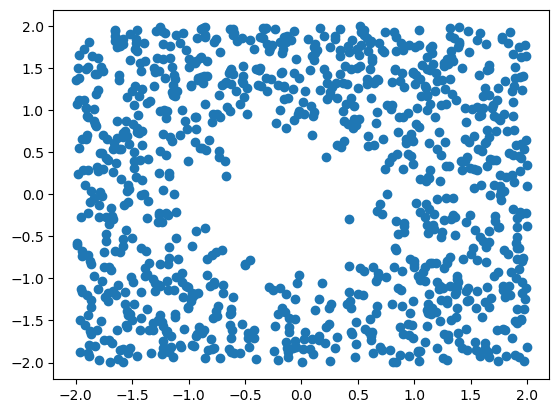

In [105]:
thetas = np.array(thetas)
print(thetas)


thetas[:,0] # theta1
thetas[:,1] # theta2

plt.scatter(thetas[:,0], thetas[:,1]) # not good.

Some observations made by me:
- If I decrease the tolerance, I can get rid of that one 1.5 column in the histogram.
- Is this some kind of inherent issue with my likelihood that I get 0.4 and -0.4 ooooooh it is, since the theta is also squared. Let's change that :D
- But if I get rid of the theta^2, the problem reduces to linear regression. And apparently, my theta is pretty heavily affected by the prior and has wide credible intervals even with low tolerance. And the mean is close to zero.
    - In fact, this is now probably the problem of a non-informative prior. What if I change it to a normal prior?
    - Ok, a uniform prior with a more bounded range did not help. The mean for thetas is still zero :,)
    - Normal prior is even more screwed up.
    

Some observations about the MA1 process
- Something is very screwed up, I get a flat posterior.... Actually, I pretty much get the prior itself. Maybe due to using the mean as summary statistic. 
- Q: What would happen, if the summary statistic was variance instead of mean?
    - Nah, still bad.
- I returned u instead of y. Typical. But it's still flat :(

MA2 process observations, two parameters.
- Again, flat. Starting to suspect my implementation.
- Changed the statistic from variance to mean. I can now see a concentration of points
- Autocovariance does not work??
- Using the median does exactly the opposite of what I want to achieve. It "deletes" the relevant area from the points :D And at the wrong position too.

In [ ]:
# Testing instead the MCMC-ABC algorithm


def mcmc_abc(N):
    
    for t in range(0, N):
        pass